# Gene expression Kappa tuning, replicate 1

In this notebook, we proof of concept that the model indeed is able to identify proper daughter-specific changes. We use the daughter-specific genes as examples where DG1 specific expression is apparent. We also contrast these changes to control genes not expected to exhibit differences.

Finally, we use a signal-to-noise ratio to quantify a proper "kappa" regularization to minimize false-positive daughter-specific changes.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [725]:
from src.config import load_default_gene_expression_configs

config1, config2 = load_default_gene_expression_configs('distinct')

todo: Loading testing config from replication deconvolution


In [726]:
from src.find_optimal_kappa import FindKappaExpression
find_kappa = FindKappaExpression(config1)

In [727]:
find_kappa.sweep_kappas()

[1/21]Kappa= 1e-06
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:02:44.474

[2/21]Kappa= 1.584893192461114e-06
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:05:22.353

[3/21]Kappa= 2.5118864315095823e-06
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:08:33.206

[4/21]Kappa= 3.981071705534969e-06
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:10:35.357

[5/21]Kappa= 6.30957344480193e-06
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:12:35.270

[6/21]Kappa= 1e-05
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:14:34.420

[7/21]Kappa= 1.584893192461114e-05
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:16:42.216

[8/21]Kappa= 2.5118864315095822e-05
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,SSK22,RPL1A,RPL1B,RPL2A,RPL2B,	00:18:53.418

[9/21]Kappa= 3.9810717055349695e-05
	DSE1,DSE2,DSE3,DSE

In [728]:
find_kappa.compute_l2tb()

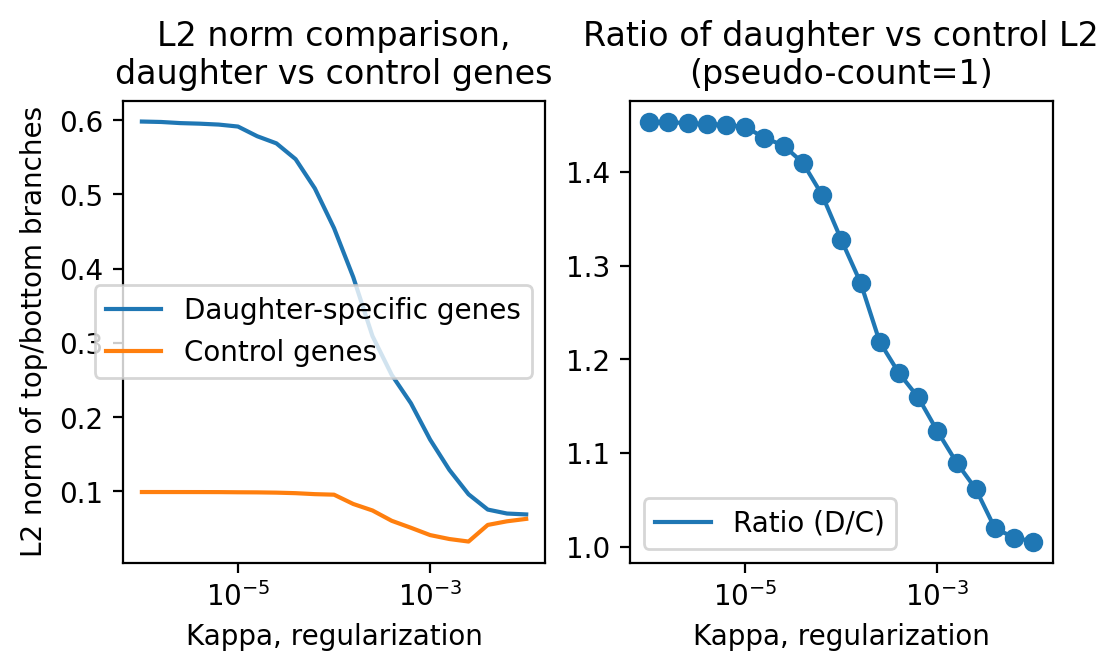

In [729]:
find_kappa.plot_l2_tb()

In [730]:
# Identify the optimal kappa value using the signal of daughter-specific expression
# compared to control gene expression

optimal_idx = 0#11#find_kappa.snr_l2.iloc[offset:].argmax()+offset
find_kappa_l2_df = pd.DataFrame(find_kappa.snr_l2)

optimal = find_kappa_l2_df.iloc[optimal_idx]
optimal_kappa, optimal_snr = optimal.name, optimal.values[0]
optimal_idx, optimal_kappa

(0, 1e-06)

In [731]:
optimal_kappa = find_kappa_l2_df.index.values[optimal_idx]

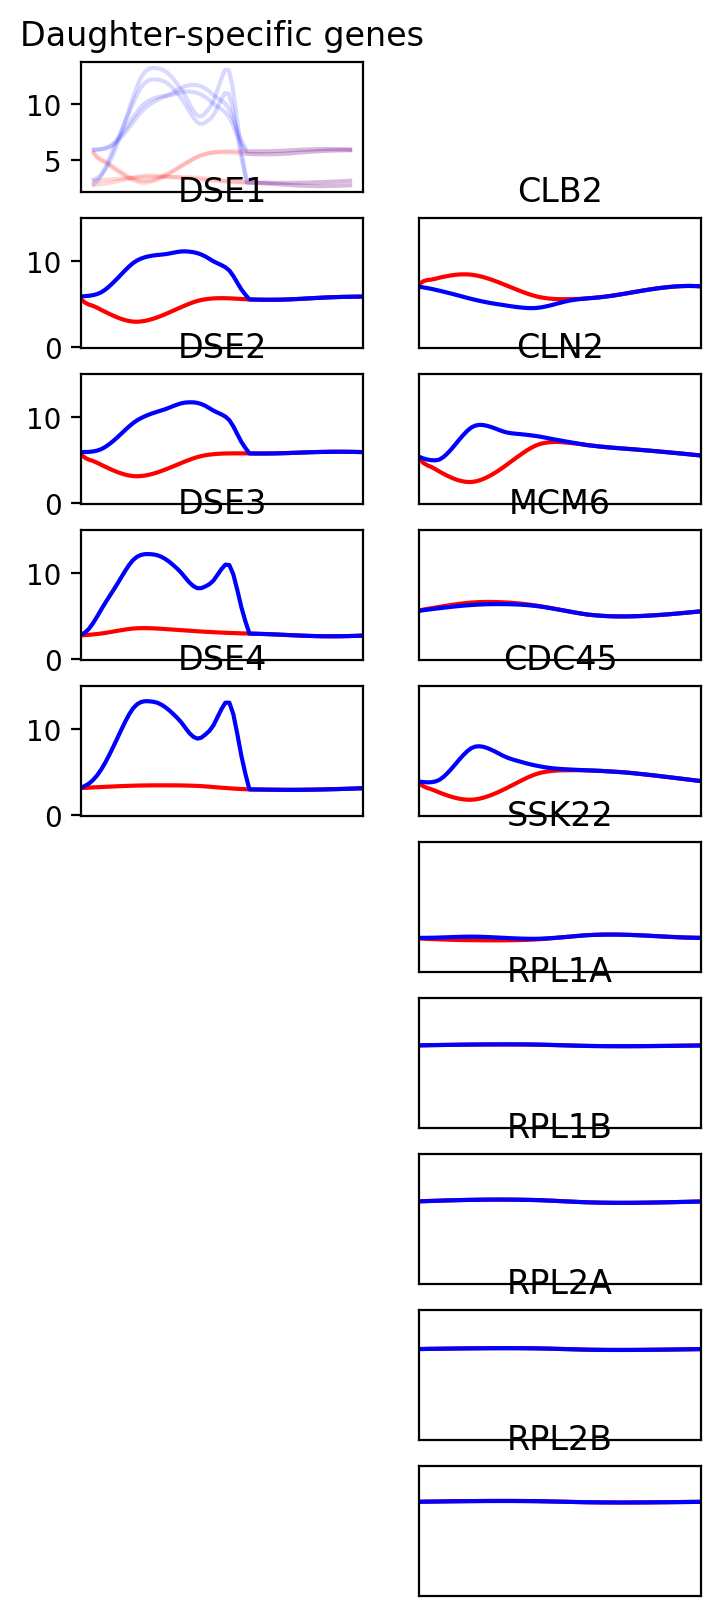

In [732]:
find_kappa.plot_top_bottom_curves(optimal_idx)

In [602]:
from src.utils import mkdir_safe

outdir = 'output/gene_expression_trial_daughter_comparison'
mkdir_safe(outdir)

Creating directory: output/gene_expression_trial_daughter_comparison...Directory exists. Skipping.


In [603]:
gene_f_solutions = find_kappa.gene_f_solutions
for gene_name, kappa in gene_f_solutions.keys():
    
    if abs(kappa - optimal_kappa) < 1e-4:
        solution_f = gene_f_solutions[(gene_name, kappa)]
        filepath = f"{outdir}/{gene_name}_expression_F.npy"
        np.save(filepath, solution_f)
        print(f"Saved to {filepath}")


Saved to output/gene_expression_trial_daughter_comparison/DSE1_expression_F.npy
Saved to output/gene_expression_trial_daughter_comparison/CLB2_expression_F.npy


	Base error (γ=0):	rn: 0.001940	sn: 218722.116493
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.00203737
			Absolute (e0 + 0.04): 0.0419404
			Chosen: 0.002037
		Right:
			Relative (4.00 * e0): 0.00776141
			Absolute (e0 + 11.00): 11.0019
			Chosen: 11.001940
	Searching for left boundary gamma...
		γ: 0.0055	rn: 0.1620	sn: 48.9023
		γ: 0.00325	rn: 0.1240	sn: 58.7985
		γ: 0.002125	rn: 0.0959	sn: 68.9474
		γ: 0.0015625	rn: 0.0650	sn: 86.0707
		γ: 0.00128125	rn: 0.0505	sn: 96.2251
		γ: 0.00114063	rn: 0.0444	sn: 101.3015
		γ: 0.00107031	rn: 0.0416	sn: 103.8402
		γ: 0.00103516	rn: 0.0402	sn: 105.1080
		γ: 0.00101758	rn: 0.0396	sn: 105.7366
		γ: 0.00100879	rn: 0.0393	sn: 106.0460
		γ: 0.00100439	rn: 0.0391	sn: 106.1963
		γ: 0.0010022	rn: 0.0391	sn: 106.2662
		γ: 0.0010011	rn: 0.0390	sn: 106.3063
		γ: 0.00100055	rn: 0.0390	sn: 106.3228
	Left boundary gamma found: 0.00100027
	Searching for right boundary gamma...
		γ: 0.00550014	rn: 0.1620	sn: 48.9038
		γ: 0.00775007	rn: 0.1811	sn: 46.

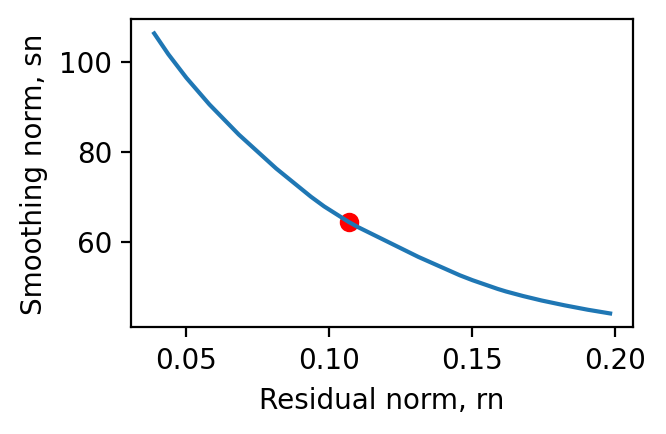

In [806]:
from src.find_optimal_kappa import load_gene_expression
from src.find_optimal_kappa import GeneExpressionFindOptimalGamma

g = load_gene_expression('MCM6')
expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g)
expression_find_gamma.find_optimal_gamma(plot=True, verbose=True, kappa=0.0)#16)

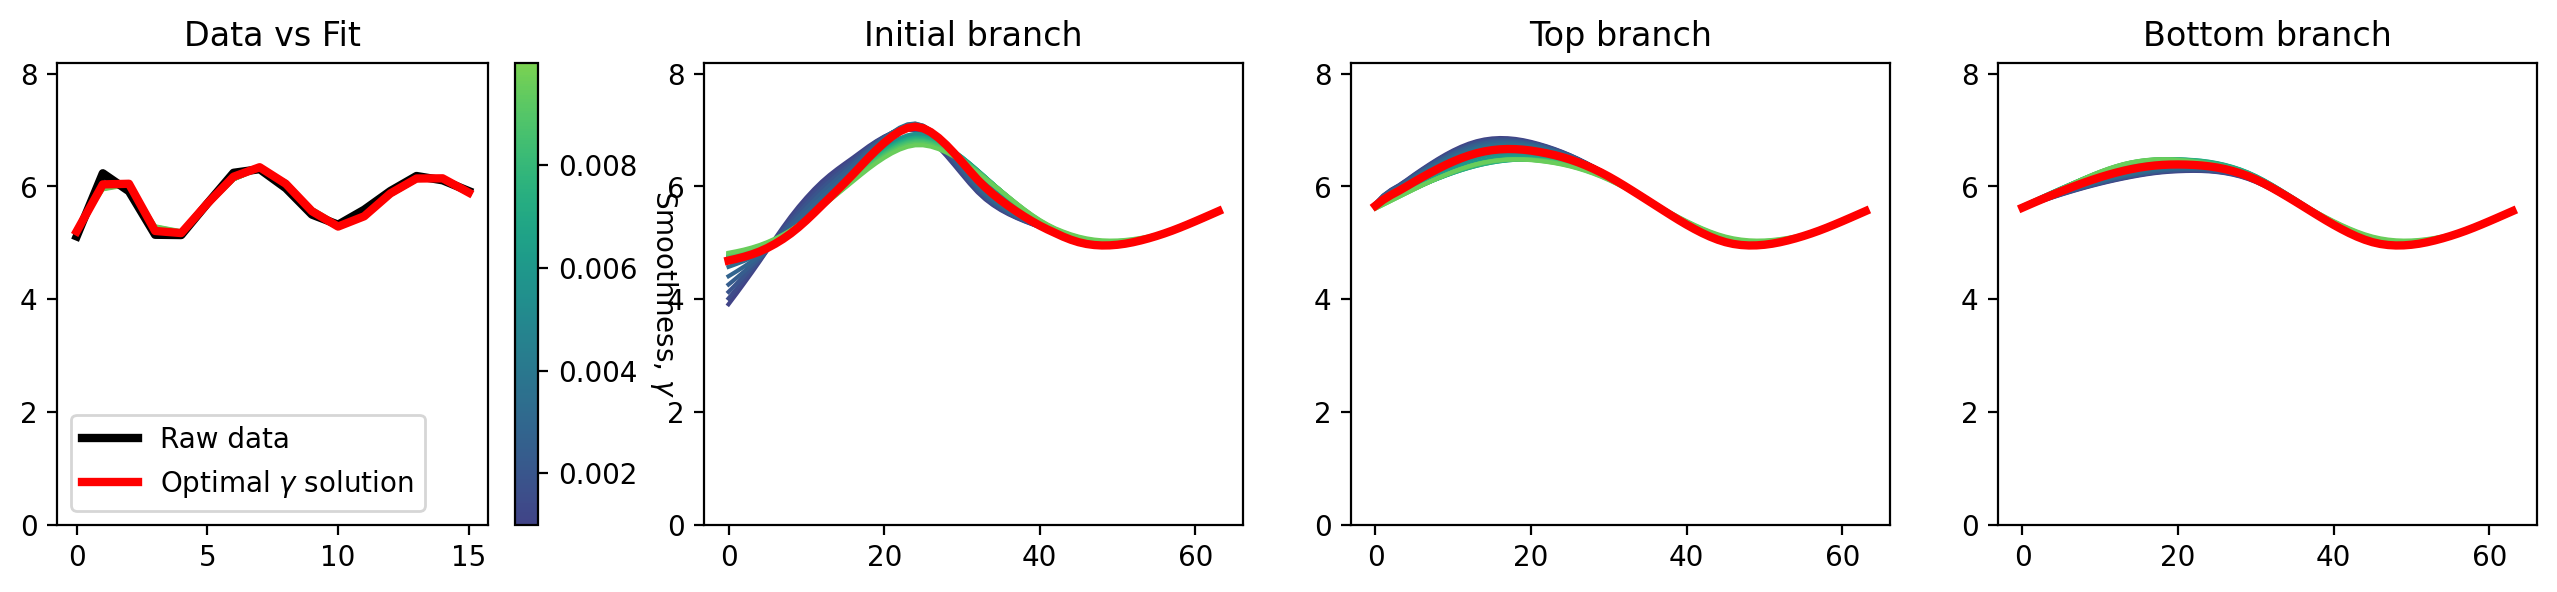

In [807]:
expression_find_gamma.plot_gamma_sweep()

In [734]:
tpm_tx = pd.read_csv('datasets/yl_cell_cycle/replicate1_gene_expression_TPM.csv').set_index('orf_name')

In [783]:
tpm_means = pd.DataFrame({'mean': tpm_tx.mean(axis=1), 'std': tpm_tx.std(axis=1)},
                        index=tpm_tx.index.values)

,mean,std
YAL068C,0.041555,0.049652
YAL067W-A,0.000000,0.000000
YAL067C,4.361335,3.295638
YAL065C,0.189587,0.171509
YAL064W-B,2.168950,0.503939
...,...,...
YPR200C,7.238490,1.910768
YPR201W,2.448470,0.647062
YPR202W,1.405077,0.435884
YPR203W,0.000000,0.000000


In [788]:
selected_genes[off_genes].sort_values('std')

,mean,std,gene,length
YNR070W,0.000983,0.002687,PDR18,4001.0
YMR170C,0.114158,0.053521,ALD2,1520.0
YIL015W,0.089754,0.058127,BAR1,1763.0
YHR054C,0.123645,0.060532,YHR054C,1064.0
YFL040W,0.196885,0.068095,YFL040W,1622.0
...,...,...,...,...
YIL160C,0.447304,0.484973,POT1,1253.0
YOR049C,0.854104,0.485436,RSB1,1064.0
YCR010C,0.987982,0.518618,ADY2,851.0
YPR078C,0.911283,0.581195,YPR078C,1118.0


In [785]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()
selected_genes = tpm_means.join(genes[['gene', 'length']])

off_genes = (selected_genes['mean'] < 1) & (selected_genes['length'] > 600)

for orf_name in off_genes.index.values:
    try:
        gene = genes.loc[orf_name]
        if (gene['length'] > 800):
            print(gene.name, gene['gene'], gene['length'], 
                tpm_tx.loc[orf_name].mean(), 
                 tpm_tx.loc[orf_name].std())
    except KeyError:
        continue


YAL067C SEO1 1781 4.3613353318084815 3.295638165378057
YAL063C FLO9 3968 0.36217096473484356 0.11398445399313967
YAL062W GDH3 1373 6.591772553059467 1.5829994699693901
YAL061W BDH2 1253 6.823263621842495 3.146106648452294
YAL060W BDH1 1148 80.4461088935229 35.14144033796436
YAL058W CNE1 1508 28.687863853807933 3.638561637738941
YAL056W GPB2 2642 40.57473729723704 4.256331802420873
YAL054C ACS1 2141 5.5590458927556705 5.576613802117319
YAL053W FLC2 2351 95.80394313668035 33.05280134723101
YAL051W OAF1 3143 19.54356656342444 1.260708523902956
YAL048C GEM1 1988 18.22931260506131 1.5856587609760304
YAL047C SPC72 1868 16.038005099602646 3.1783111857618533
YAL043C PTA1 2357 46.34254485978119 2.5606171719964106
YAL042W ERV46 1247 230.28917123230508 13.784728225894627
YAL041W CDC24 2564 44.22588126174564 2.6865033835001735
YAL040C CLN3 1742 55.96272934229275 19.773198366956564
YAL039C CYC3 809 59.02789235284074 23.94067840490607
YAL038W CDC19 1502 8810.747296459242 770.4939517692624
YAL037W YA

YER016W BIM1 1034 73.1115291138866 15.827008262080525
YER017C AFG3 2285 48.03044465861942 6.176215613935864
YER019W ISC1 1433 68.90762891051703 35.00388304945034
YER020W GPA2 1349 33.97716941972874 10.949217131242534
YER021W RPN3 1571 177.7769757332855 37.127129031680056
YER022W SRB4 2063 35.11383223356309 1.628828252602039
YER023W PRO3 860 325.1510655004512 43.875464455817365
YER024W YAT2 2771 13.396914179082799 9.605796727512542
YER025W GCD11 1583 378.0114136669578 41.26994199565334
YER026C CHO1 830 136.13315245968803 26.20962884612224
YER027C GAL83 1253 61.6683314327058 10.567756077438705
YER028C MIG3 1184 13.193625891109598 3.1456588129138328
YER032W FIR1 2630 17.737384152484914 7.0033013575299945
YER033C ZRG8 3230 9.977839638042077 2.755319815386979
YER036C ARB1 1832 495.2464596354728 77.02361004898941
YER037W PHM8 965 48.271118023211514 23.84971561499883
YER038C KRE29 1394 14.91084512408153 1.926127958701814
YER040W GLN3 2192 16.63387841285539 1.2839282893041075
YER041W YEN1 2279

YKL198C PTK1 1988 9.121149807120307 1.7858384071463336
YKL197C PEX1 3131 22.185161401013346 2.8410903938533876
YKL195W MIA40 1211 119.41578591421096 38.57871537783639
YKL194C MST1 1388 22.507866816159925 4.764679937742647
YKL193C SDS22 1016 45.39193009846005 13.305400883921848
YKL191W DPH2 1604 95.21459785043118 22.074442835656008
YKL189W HYM1 1199 68.20614512789487 65.47778667837139
YKL188C PXA2 2561 7.329972400011486 1.571216255476916
YKL187C YKL187C 2252 4.007506844606308 0.617622074499066
YKL185W ASH1 1766 50.6822779725751 34.20440199104326
YKL184W SPE1 1400 137.9642774691462 15.862926012719019
YKL183W LOT5 920 40.74124768125324 9.401099695032746
YKL182W FAS1 6155 633.5381583677349 108.84661375414753
YKL181W PRS1 1283 392.7604811908391 62.696620926672516
YKL180W RPL17A 860 1498.6733733015271 258.3304329512559
YKL179C COY1 2039 57.54085092079213 6.629266219487495
YKL178C STE3 1412 0.8559345092140314 0.2836208999898505
YKL176C LST4 2486 70.1064745843999 4.4873996083627485
YKL175W ZRT

YML069W POB3 1658 127.85127505692073 25.950925826939788
YML068W ITT1 1394 19.570835343390343 2.8608689991123573
YML067C ERV41 1151 77.6544154794436 7.713262579411454
YML066C SMA2 1109 0.1735236893803384 0.09670594574796668
YML065W ORC1 2744 35.654876524991394 9.308606091023442
YML062C MFT1 1178 35.9334772977602 6.633136538920416
YML061C PIF1 2579 32.41376162938967 14.050969355618706
YML060W OGG1 1130 32.90954731571288 18.22149481128041
YML059C NTE1 5039 30.015033091551125 7.368794454191723
YML057W CMP2 1814 59.018227998300304 22.969279622469365
YML056C IMD4 1982 610.4116798665648 177.01773534743094
YML054C CYB2 1775 6.852530361978554 4.906429301491277
YML052W SUR7 908 141.38469697744821 89.39373020747097
YML051W GAL80 1307 56.69642814686813 2.4204372271877914
YML050W AIM32 935 10.801776779749638 0.8816836729577626
YML049C RSE1 4085 29.669737473026412 2.676532307095832
YML048W GSF2 1211 205.8187446144907 33.45684644467356
YML047C PRM6 1058 59.79361727997404 99.51149129197903
YML046W PRP

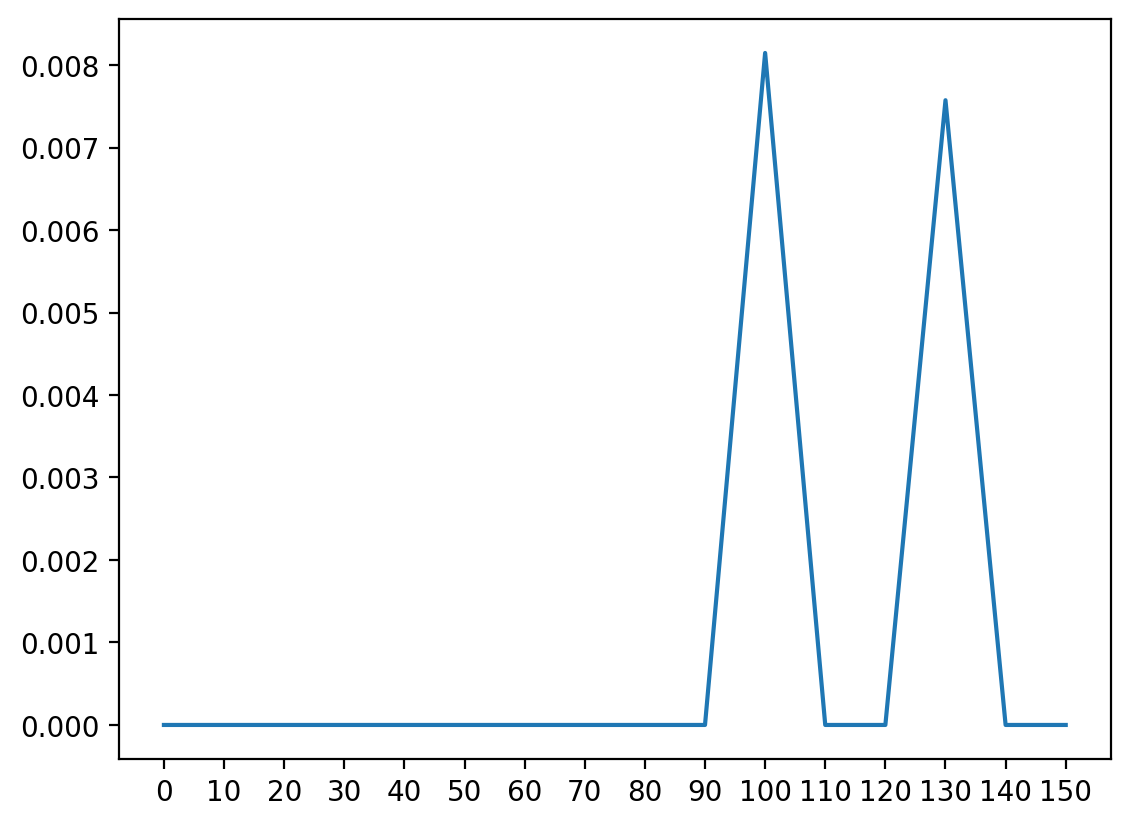

In [789]:
plt.plot(tpm_tx.loc['YNR070W'])